# Titanic Dataset Analysis

## Objective
The objective of this project is to analyze the Titanic dataset and identify factors that influenced passenger survival. The analysis focuses on gender, passenger class, and age groups using Python data analysis and visualization libraries.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load the Titanic Dataset

The Titanic dataset is loaded from a CSV file downloaded from Kaggle. This dataset contains information about passengers such as age, gender, passenger class, fare, and survival status.

In [5]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S


## Step 2: Explore the Dataset

Before performing analysis, we inspect the dataset structure, data types, and available columns.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  5 non-null      int64  
 1   Survived     5 non-null      int64  
 2   Pclass       5 non-null      int64  
 3   Name         5 non-null      object 
 4   Sex          5 non-null      object 
 5   Age          5 non-null      int64  
 6   SibSp        5 non-null      int64  
 7   Parch        5 non-null      int64  
 8   Ticket       5 non-null      object 
 9   Fare         5 non-null      float64
 10  Cabin        2 non-null      object 
 11  Embarked     5 non-null      object 
dtypes: float64(1), int64(6), object(5)
memory usage: 608.0+ bytes


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,5.000000,5.000000,5.000000,5.00000,5.000000,5.0,5.000000
mean,3.000000,0.600000,2.200000,31.20000,0.600000,0.0,29.521660
std,1.581139,0.547723,1.095445,6.83374,0.547723,0.0,30.510029
min,1.000000,0.000000,1.000000,22.00000,0.000000,0.0,7.250000
25%,2.000000,0.000000,1.000000,26.00000,0.000000,0.0,7.925000
50%,3.000000,1.000000,3.000000,35.00000,1.000000,0.0,8.050000
75%,4.000000,1.000000,3.000000,35.00000,1.000000,0.0,53.100000
max,5.000000,1.000000,3.000000,38.00000,1.000000,0.0,71.283300


## Step 3: Check for Missing Values

Real-world datasets often contain missing values. Identifying these missing values helps determine appropriate data cleaning methods.

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          3
Embarked       0
dtype: int64

## Step 4: Data Cleaning

To improve data quality:

- Missing Age values are replaced with the median age.
- Missing Embarked values are replaced with the most frequent value.
- Cabin column is removed because it contains many missing values.

In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.drop('Cabin', axis=1, inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Analysis 1: Survival Based on Gender

This analysis investigates whether gender influenced survival during the Titanic disaster.

### Research Question
Who survived more: males or females?

In [13]:
gender_survival = df.groupby('Sex')['Survived'].sum()

print(gender_survival)

Sex
female    3
male      0
Name: Survived, dtype: int64


## Visualization 1: Survival by Gender

The following bar chart compares the number of survivors and non-survivors among male and female passengers.

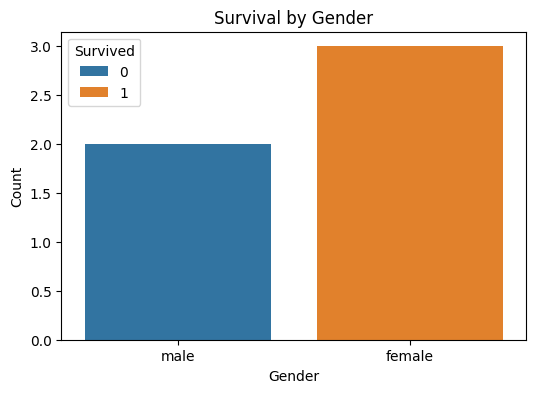

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

## Analysis 2: Survival Based on Passenger Class

Passenger class may have affected access to lifeboats and safety measures.

### Research Question
Did passenger class affect survival chances?

In [16]:
class_survival = df.groupby('Pclass')['Survived'].mean() * 100

print(class_survival)

Pclass
1    100.000000
3     33.333333
Name: Survived, dtype: float64


## Visualization 2: Survival by Passenger Class

This chart shows survival counts for passengers belonging to different travel classes.

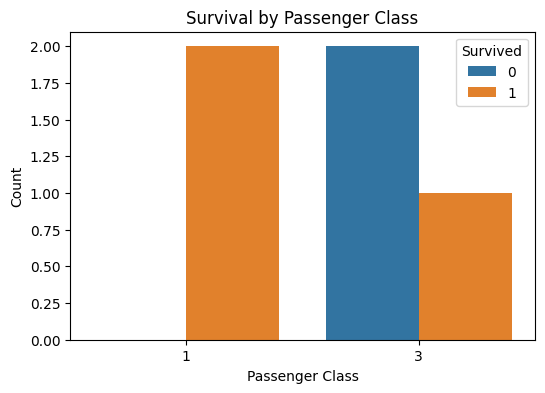

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.show()

## Analysis 3: Survival Rate by Age Group

Passengers are categorized into different age groups to study how age influenced survival rates.

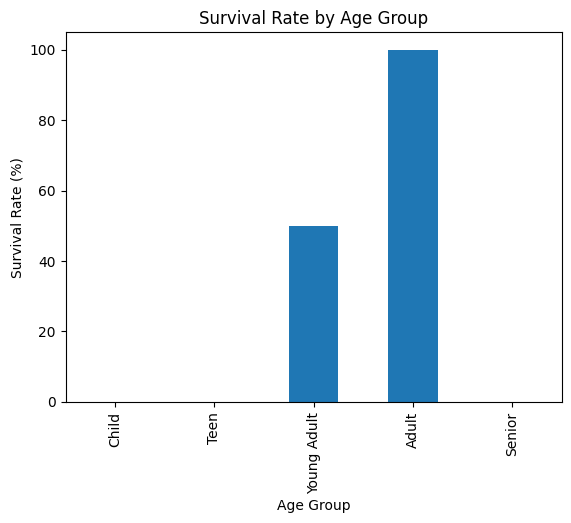

In [20]:
age_survival = df.groupby('AgeGroup', observed=False)['Survived'].mean() * 100

age_survival.plot(kind='bar')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.show()

## Visualization 3: Distribution of Passenger Ages

A histogram is used to visualize the age distribution of passengers aboard the Titanic.

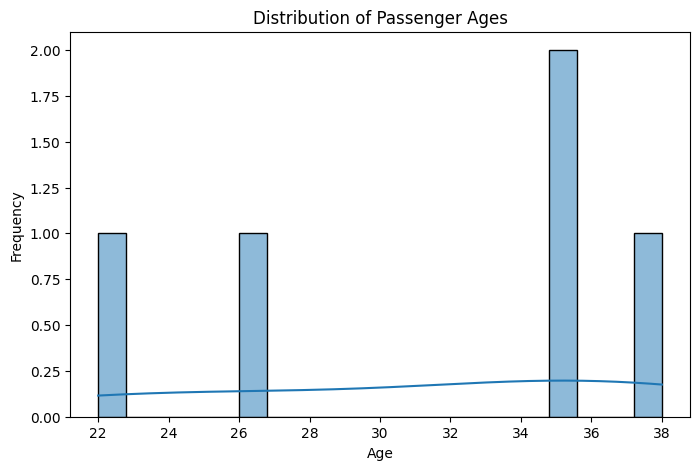

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

# Conclusion

### Key Findings

1. Female passengers had a higher survival rate than male passengers.
2. Passenger class significantly influenced survival chances.
3. Survival rates varied among different age groups.
4. Visualizations helped identify important patterns in the dataset.

This project demonstrates data cleaning, exploratory data analysis, and data visualization using Python.

In [23]:
print("Analysis Completed Successfully")

Analysis Completed Successfully
